In [1]:
import os
import numpy as np
import netCDF4 as nc

# =========================================================
# 
# =========================================================
input_file = "/scratch/smliu01/1d_model/climatechange/urad_below32_fit_above32_HMshear_501_1000.nc"
output_dir = "/scratch/smliu01/1d_model/climatechange/urad_timevarying_4experiments"

urad_name = "urad"

# =========================================================
# 
# =========================================================
# gamma_upper =  32 km  upper shear 
# gamma_lowmid =  15-32 km lower/middle shear 
#
# 0.4  upper shear  40%
# -0.2  lower/middle shear  20%
# +0.2  lower/middle shear  20%
# =========================================================
experiments = {
    "ctl": {
        "gamma_upper": 0.0,
        "gamma_lowmid": 0.0,
    },

    "A_upper_only": {
        "gamma_upper": 0.5,
        "gamma_lowmid": 0.0,
    },

    "C_upper_plus_lowmid_comp": {
        "gamma_upper": 0.5,
        "gamma_lowmid": -0.2,
    },

    "D_upper_plus_lowmid_enhance": {
        "gamma_upper": 0.5,
        "gamma_lowmid": 0.2,
    },
}

# =========================================================
# 
# =========================================================
#  32 km  upper shear  reference
z_ref_km = 32.0

# upper response: 32 km 
z_upper_start_km = 32.0
upper_transition_width_km = 4.0

# lower/middle response: 15-32 km
z_lowmid_bottom_km = 10.0
z_lowmid_top_km = 32.0
lowmid_transition_width_km = 2.0

# =========================================================
# 
# =========================================================
def copy_dimensions_and_attrs(src, dst):
    """ dimensions  global attributes"""
    for dname, dim in src.dimensions.items():
        dst.createDimension(
            dname,
            len(dim) if not dim.isunlimited() else None
        )

    for attr in src.ncattrs():
        dst.setncattr(attr, src.getncattr(attr))


def copy_all_variables(src, dst):
    """ attributes """
    for vname, varin in src.variables.items():
        outvar = dst.createVariable(
            vname,
            varin.datatype,
            varin.dimensions
        )

        for attr in varin.ncattrs():
            outvar.setncattr(attr, varin.getncattr(attr))

        outvar[:] = varin[:]


def smooth_step_up(z, z0, width):
    """
     0  1

    z << z0:  0
    z >> z0:  1
    """
    return 0.5 * (1.0 + np.tanh((z - z0) / width))


def smooth_step_down(z, z0, width):
    """
     1  0

    z << z0:  1
    z >> z0:  0
    """
    return 0.5 * (1.0 - np.tanh((z - z0) / width))


def make_lowmid_window(z, z_bottom, z_top, width):
    """
     lower/middle window

     z_bottom  z_top  1
     0
    """
    up_from_bottom = smooth_step_up(z, z_bottom, width)
    down_from_top = smooth_step_down(z, z_top, width)
    return up_from_bottom * down_from_top


# =========================================================
# 
# =========================================================
os.makedirs(output_dir, exist_ok=True)

with nc.Dataset(input_file, "r") as src:

    # -----------------------------------------------------
    # 
    # -----------------------------------------------------
    if urad_name not in src.variables:
        raise ValueError(f"Cannot find variable '{urad_name}' in {input_file}")

    if "height" not in src.variables:
        raise ValueError("Cannot find variable 'height' in the input file.")

    urad_ctl = src.variables[urad_name][:].astype(np.float64)
    height = src.variables["height"][:].astype(np.float64)

    if urad_ctl.ndim != 3:
        raise ValueError(
            f"{urad_name} must be 3D with dimensions (height, year, time). "
            f"Current shape = {urad_ctl.shape}"
        )

    zdim, nyear, ntime = urad_ctl.shape

    print("=================================================")
    print("[INFO] input file:", input_file)
    print("[INFO] output dir:", output_dir)
    print("[INFO] urad shape:", urad_ctl.shape)
    print("[INFO] height range:", height.min(), "to", height.max(), "km")
    print("[INFO] nyear =", nyear, "ntime =", ntime)

    # -----------------------------------------------------
    #  32 km
    # -----------------------------------------------------
    z_ref_idx = int(np.argmin(np.abs(height - z_ref_km)))
    z_ref_actual = float(height[z_ref_idx])

    print("-------------------------------------------------")
    print(f"[INFO] z_ref target = {z_ref_km:.2f} km")
    print(f"[INFO] z_ref index  = {z_ref_idx}")
    print(f"[INFO] z_ref actual = {z_ref_actual:.3f} km")

    # shape = (1, year, time) broadcast
    u_ref = urad_ctl[z_ref_idx:z_ref_idx + 1, :, :]

    # -----------------------------------------------------
    #  ramp 0 1
    # -----------------------------------------------------
    if nyear == 1:
        year_ramp = np.ones(nyear, dtype=np.float64)
    else:
        year_ramp = np.linspace(0.0, 1.0, nyear, dtype=np.float64)

    ramp3d = year_ramp[None, :, None]

    print("-------------------------------------------------")
    print("[INFO] year ramp:")
    print("       first year  =", year_ramp[0])
    print("       middle year =", year_ramp[nyear // 2])
    print("       last year   =", year_ramp[-1])

    # -----------------------------------------------------
    # 
    # -----------------------------------------------------
    # upper weight:
    # 32 km  032 km  1
    w_upper = smooth_step_up(
        height,
        z_upper_start_km,
        upper_transition_width_km
    )
    w_upper[height < z_upper_start_km] = 0.0

    # low/mid window:
    # 15-32 km 32 km  0
    w_lowmid = make_lowmid_window(
        height,
        z_lowmid_bottom_km,
        z_lowmid_top_km,
        lowmid_transition_width_km
    )
    w_lowmid[height >= z_lowmid_top_km] = 0.0

    w_upper3d = w_upper[:, None, None]
    w_lowmid3d = w_lowmid[:, None, None]

    print("-------------------------------------------------")
    print("[INFO] vertical weight examples:")
    for zz in [10, 12, 15, 20, 25, 30, 32, 35, 40, 45, 50]:
        idx = int(np.argmin(np.abs(height - zz)))
        print(
            f"       z = {height[idx]:6.2f} km, "
            f"w_upper = {w_upper[idx]:.3f}, "
            f"w_lowmid = {w_lowmid[idx]:.3f}"
        )

    # -----------------------------------------------------
    # shear relative to 32 km
    # -----------------------------------------------------
    # du > 0 positive gamma  urad 
    # du < 0 positive gamma  urad 
    #  32 km  vertical shear
    du = urad_ctl - u_ref

    # -----------------------------------------------------
    # 
    # -----------------------------------------------------
    print("-------------------------------------------------")
    print("[INFO] generating experiment files...")

    for exp_name, pars in experiments.items():

        gamma_upper = float(pars["gamma_upper"])
        gamma_lowmid = float(pars["gamma_lowmid"])

        total_weight3d = (
            gamma_upper * w_upper3d
            + gamma_lowmid * w_lowmid3d
        )

        # 
        # u_new = u_ctl + T(year) * [gamma_upper*w_upper + gamma_lowmid*w_lowmid] * (u_ctl - u_ref)
        urad_new = urad_ctl + ramp3d * total_weight3d * du

        outfile = os.path.join(
            output_dir,
            f"urad_{exp_name}_timevarying.nc"
        )

        with nc.Dataset(outfile, "w", format="NETCDF4") as dst:
            copy_dimensions_and_attrs(src, dst)
            copy_all_variables(src, dst)

            # overwrite urad
            dst.variables[urad_name][:] = urad_new.astype(np.float32)

            # metadata
            dst.setncattr("experiment_name", exp_name)
            dst.setncattr("gamma_upper_final", gamma_upper)
            dst.setncattr("gamma_lowmid_final", gamma_lowmid)
            dst.setncattr("z_ref_km_target", float(z_ref_km))
            dst.setncattr("z_ref_km_actual", z_ref_actual)
            dst.setncattr("z_ref_index", int(z_ref_idx))
            dst.setncattr("z_upper_start_km", float(z_upper_start_km))
            dst.setncattr("upper_transition_width_km", float(upper_transition_width_km))
            dst.setncattr("z_lowmid_bottom_km", float(z_lowmid_bottom_km))
            dst.setncattr("z_lowmid_top_km", float(z_lowmid_top_km))
            dst.setncattr("lowmid_transition_width_km", float(lowmid_transition_width_km))
            dst.setncattr(
                "description",
                "Time-varying climate-change uRAD perturbation. "
                "Formula: u_new = u_ctl + T(year) * "
                "[gamma_upper*w_upper(z) + gamma_lowmid*w_lowmid(z)] "
                "* [u_ctl(z,year,time) - u_ctl(z_ref,year,time)]. "
                "T(year) increases linearly from 0 in the first year to 1 in the last year. "
                "gamma values are dimensionless shear-scaling factors."
            )

        # 
        diff = urad_new - urad_ctl
        print(f"[OK] wrote: {outfile}")
        print(f"     gamma_upper={gamma_upper:+.2f}, gamma_lowmid={gamma_lowmid:+.2f}")
        print(f"     diff min/max = {np.nanmin(diff):+.3f}, {np.nanmax(diff):+.3f} m/s")

print("=================================================")
print("[DONE] All time-varying uRAD experiment files generated.")

[INFO] input file: /scratch/smliu01/1d_model/climatechange/urad_below32_fit_above32_HMshear_501_1000.nc
[INFO] output dir: /scratch/smliu01/1d_model/climatechange/urad_timevarying_4experiments
[INFO] urad shape: (501, 1000, 992)
[INFO] height range: 10.0 to 109.80039978027344 km
[INFO] nyear = 1000 ntime = 992
-------------------------------------------------
[INFO] z_ref target = 32.00 km
[INFO] z_ref index  = 110
[INFO] z_ref actual = 31.956 km
-------------------------------------------------
[INFO] year ramp:
       first year  = 0.0
       middle year = 0.5005005005005005
       last year   = 1.0
-------------------------------------------------
[INFO] vertical weight examples:
       z =  10.00 km, w_upper = 0.000, w_lowmid = 0.500
       z =  12.00 km, w_upper = 0.000, w_lowmid = 0.880
       z =  14.99 km, w_upper = 0.000, w_lowmid = 0.993
       z =  19.98 km, w_upper = 0.000, w_lowmid = 1.000
       z =  24.97 km, w_upper = 0.000, w_lowmid = 0.999
       z =  29.96 km, w_uppe

[INFO] loaded experiments
       control: ctl, shape = (501, 1000)
       Top: A_upper_only, shape = (501, 1000)
       Top + Bottom: C_upper_plus_lowmid_comp, shape = (501, 1000)
       Top - Bottom: D_upper_plus_lowmid_enhance, shape = (501, 1000)
[INFO] year range: 1 to 1000
[INFO] height range: 10.0 to 109.80039978027344
-------------------------------------------------
[INFO] colorbar range: -12.000 to 12.000 m/s
[SAVED] /scratch/smliu01/1d_model/climatechange/urad_timevarying_4experiments/figures/urad_3experiments_year_height_difference_contours.png
[SAVED] /scratch/smliu01/1d_model/climatechange/urad_timevarying_4experiments/figures/urad_3experiments_year_height_difference_contours.pdf


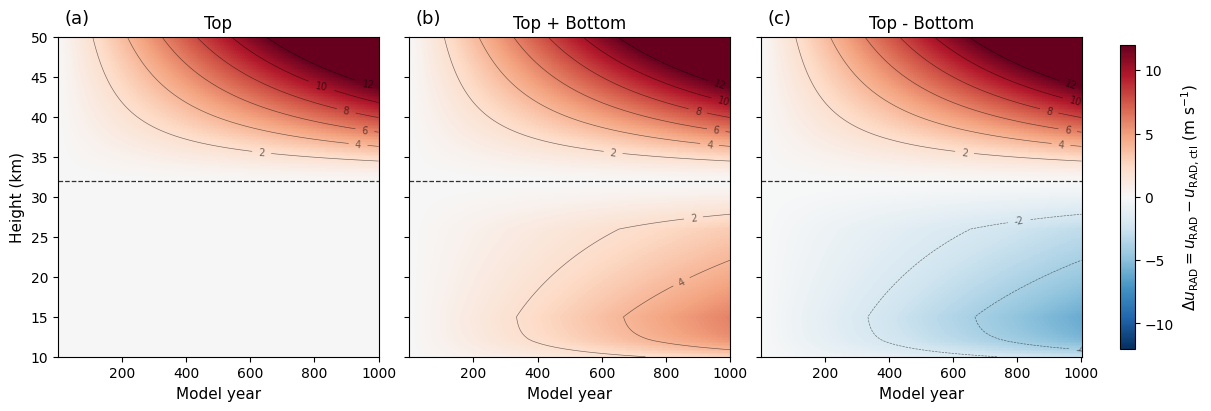

In [2]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

# =========================================================
# 
# =========================================================
input_dir = "/scratch/smliu01/1d_model/climatechange/urad_timevarying_4experiments"
output_dir = os.path.join(input_dir, "figures")
os.makedirs(output_dir, exist_ok=True)

urad_name = "urad"
height_name = "height"

# =========================================================
# 
# =========================================================
control_exp = "ctl"

diff_experiments = [
    "A_upper_only",
    "C_upper_plus_lowmid_comp",
    "D_upper_plus_lowmid_enhance",
]

#  model  SSW 
display_names = {
    "A_upper_only": "Top",
    "C_upper_plus_lowmid_comp": "Top + Bottom",
    "D_upper_plus_lowmid_enhance": "Top - Bottom",
}

panel_labels = {
    "A_upper_only": "(a)",
    "C_upper_plus_lowmid_comp": "(b)",
    "D_upper_plus_lowmid_enhance": "(c)",
}

files = {
    control_exp: os.path.join(input_dir, f"urad_{control_exp}_timevarying.nc")
}

for exp in diff_experiments:
    files[exp] = os.path.join(input_dir, f"urad_{exp}_timevarying.nc")

# =========================================================
# 
# =========================================================
zmin = 10
zmax = 50

max_year_plot = None
# max_year_plot = 200

fixed_vmax = 12
# fixed_vmax = None

save_pdf = True

# contour line 
add_contours = True

#  2 m/s  contour
contour_interval = 2.0

#  contour 
label_contours = True


# =========================================================
# 
# =========================================================
def read_urad_year_height(filename):
    """
     urad(height, year, time) time 
    :
        urad_yh: shape = (height, year)
        height : shape = (height,)
    """
    with nc.Dataset(filename, "r") as ds:
        if urad_name not in ds.variables:
            raise ValueError(f"Cannot find variable '{urad_name}' in {filename}")
        if height_name not in ds.variables:
            raise ValueError(f"Cannot find variable '{height_name}' in {filename}")

        urad = ds.variables[urad_name][:].astype(np.float64)
        height = ds.variables[height_name][:].astype(np.float64)

    if urad.ndim != 3:
        raise ValueError(
            f"{filename}: {urad_name} should be 3D with dimensions "
            f"(height, year, time), got shape {urad.shape}"
        )

    # average over time dimension
    urad_yh = np.nanmean(urad, axis=2)

    if max_year_plot is not None:
        urad_yh = urad_yh[:, :max_year_plot]

    return urad_yh, height


# =========================================================
# 
# =========================================================
data = {}
height_ref = None

for exp, f in files.items():
    if not os.path.exists(f):
        raise FileNotFoundError(f"Cannot find file: {f}")

    urad_yh, height = read_urad_year_height(f)
    data[exp] = urad_yh

    if height_ref is None:
        height_ref = height
    else:
        if not np.allclose(height_ref, height):
            raise ValueError(f"Height coordinate mismatch in {f}")

height = height_ref
ctl = data[control_exp]

nyear = ctl.shape[1]
years = np.arange(1, nyear + 1)

zmask = (height >= zmin) & (height <= zmax)

print("=================================================")
print("[INFO] loaded experiments")
print(f"       control: {control_exp}, shape = {ctl.shape}")
for exp in diff_experiments:
    print(f"       {display_names[exp]}: {exp}, shape = {data[exp].shape}")
print("[INFO] year range:", years[0], "to", years[-1])
print("[INFO] height range:", height.min(), "to", height.max())


# =========================================================
#  difference ctl - ctl
# =========================================================
diff_data = {}

for exp in diff_experiments:
    diff_data[exp] = data[exp] - ctl

#  colorbar
all_diff = np.concatenate([
    diff_data[exp][zmask, :].ravel()
    for exp in diff_experiments
])
all_diff = all_diff[np.isfinite(all_diff)]

if fixed_vmax is None:
    vmax_diff = np.nanpercentile(np.abs(all_diff), 98)
else:
    vmax_diff = fixed_vmax

vmin_diff = -vmax_diff

print("-------------------------------------------------")
print(f"[INFO] colorbar range: {vmin_diff:.3f} to {vmax_diff:.3f} m/s")


# =========================================================
# contour levels
# =========================================================
contour_levels = np.arange(
    np.ceil(vmin_diff / contour_interval) * contour_interval,
    vmax_diff + contour_interval,
    contour_interval
)

#  00 
contour_levels_nozero = contour_levels[np.abs(contour_levels) > 1e-10]


# =========================================================
# 3 panels difference
# =========================================================
fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

axes = np.asarray(axes).ravel()

mappable = None

for ax, exp in zip(axes, diff_experiments):

    plot_data = diff_data[exp]

    mappable = ax.pcolormesh(
        years,
        height,
        plot_data,
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin_diff,
        vmax=vmax_diff
    )

    # =====================================================
    #  contour lines
    # =====================================================
    if add_contours:
        cs = ax.contour(
            years,
            height,
            plot_data,
            levels=contour_levels_nozero,
            colors="k",
            linewidths=0.45,
            alpha=0.55
        )

        # # 0 contour line
        # cs0 = ax.contour(
        #     years,
        #     height,
        #     plot_data,
        #     levels=[0],
        #     colors="k",
        #     linewidths=1.0,
        #     linestyles="-"
        # )

        if label_contours:
            ax.clabel(
                cs,
                inline=True,
                fontsize=7,
                fmt="%.0f"
            )

    # 32 km reference line
    ax.axhline(32, color="k", ls="--", lw=0.9, alpha=0.8)

    # panel label
    ax.text(
        0.02, 1.03,
        panel_labels[exp],
        transform=ax.transAxes,
        fontsize=13,
        ha="left",
        va="bottom"
    )

    ax.set_title(display_names[exp], fontsize=12)
    ax.set_xlabel("Model year", fontsize=11)
    ax.set_ylim(zmin, zmax)

axes[0].set_ylabel("Height (km)", fontsize=11)

cbar = fig.colorbar(mappable, ax=axes, shrink=0.95, pad=0.02)
cbar.set_label(
    r"$\Delta u_{\mathrm{RAD}} = u_{\mathrm{RAD}} - u_{\mathrm{RAD,ctl}}$ (m s$^{-1}$)",
    fontsize=11
)

# fig.suptitle(
#     r"Year-height difference of prescribed $u_{\mathrm{RAD}}$ perturbations",
#     fontsize=15
# )

outfile_png = os.path.join(
    output_dir,
    "urad_3experiments_year_height_difference_contours.png"
)

fig.savefig(outfile_png, dpi=300, bbox_inches="tight")
print("[SAVED]", outfile_png)

if save_pdf:
    outfile_pdf = os.path.join(
        output_dir,
        "urad_3experiments_year_height_difference_contours.pdf"
    )
    fig.savefig(outfile_pdf, bbox_inches="tight")
    print("[SAVED]", outfile_pdf)

plt.show()